In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [2]:
import dataset, features, plots
import pandas as pd

### Połączenie danych z Yahoo Finance i EODHD

In [3]:
yf_data: dict[str, pd.DataFrame] = dataset.YahooFinance.load()
eodhd_data: dict[str, pd.DataFrame] = dataset.EODHD.load()

merged_data: dict[str, pd.DataFrame] = features.merge_price_data(
    primary_data=eodhd_data,
    supplemental_data=yf_data,
)

features.save_merged_data(merged_data)

Saved Adj_Close.csv (24793 rows x 1200 columns)
Saved Close.csv (24793 rows x 1200 columns)
Saved Dividends.csv (24779 rows x 825 columns)
Saved High.csv (24793 rows x 1200 columns)
Saved Low.csv (24793 rows x 1200 columns)
Saved Open.csv (24793 rows x 1200 columns)
Saved Stock_Splits.csv (24779 rows x 825 columns)
Saved Volume.csv (24793 rows x 1200 columns)


Po połączeniu danych z YahooFinance i EODHD wyniki analizy pokrycia nie wykazują różnicy. Oznacza to, że tych danych, których nie ma w EODHD, nie ma również w danych z YahooFinance.

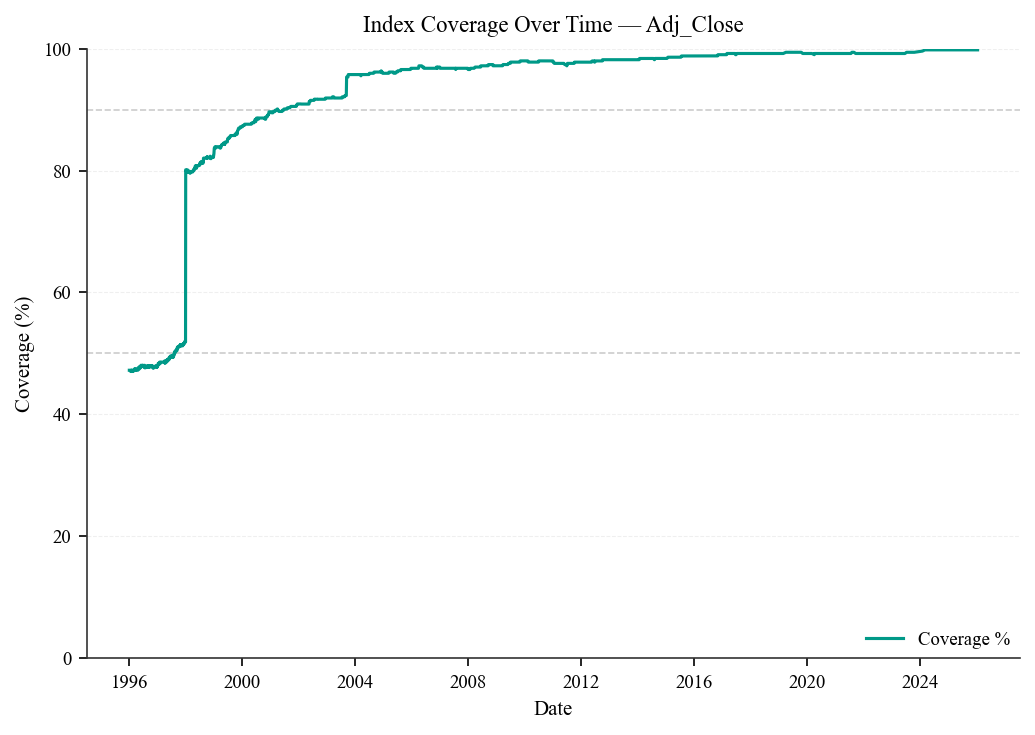

Missing ticker coverage periods:
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABI:
  missing from 1996-01-02 to 1997-12-29
  missing from 2008-11-18 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABS:
  missing from 1996-01-02 to 1997-12-29
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACKH:
  missing from 1996-01-02 to 1997-12-29
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2003-09-08
  missing from 2005-05-13 to 2005-06-06
- AET:
  missing from 1996-01-02 to 1997-12-29
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-03-22
- AHM:
  missing from 1996-01-02 to 1997-12-29
- AL:
  missing from 1996-01-02 to 2002-07-18
- AM:
  missing from 1996-01-02 to 1997-12-29
- AMH:
  missing from 1996-01-02 to 1997-09-08
- AMP:
  missing from 1996-01-02 to 1999-03-30
- ANDW:
  missing from 1996-01-02 to 1997-12-29
- ANRZQ:
  missing from 2011-06-02

,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,453.48946396,43.25988909,0.00000000,496.74935305,91.18641310
std,70.87344425,66.98565901,0.00000000,5.16624733,13.74301004
min,229.00000000,1.00000000,0.00000000,487.00000000,47.02258727
25%,447.00000000,8.00000000,0.00000000,494.00000000,90.30303030
50%,482.00000000,15.00000000,0.00000000,497.00000000,96.98189135
75%,489.00000000,48.00000000,0.00000000,499.00000000,98.39034205
max,503.00000000,258.00000000,0.00000000,507.00000000,99.80158730


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,230,257,0,487,47.22792608
1996-01-03,230,257,0,487,47.22792608
2025-12-22,502,1,0,503,99.80119284
2026-01-14,502,1,0,503,99.80119284


In [ ]:
sp500_components: pd.DataFrame = dataset.SP500.load_historical()

coverage: pd.DataFrame = plots.coverage_over_time(
    price_data=merged_data,
    components=sp500_components,
    filename="21-merged-coverage-over-time.png"
)

plots.summarize_df(coverage_df)

### Uzupełnienie brakujących danych

Aby ograniczyć wpływ błędu przeżywalności, należy uwzględnić zwroty z akcji spółek, dla których brakuje danych w zbiorze. Błąd ten zazwyczaj prowadzi do zawyżenia stóp zwrotu portfeli, co skutkuje nierealistycznymi wynikami i błędnymi wnioskami. Można go ograniczyć na dwa sposoby:

1. **Ograniczenie okna czasowego** – uwzględniać tylko okres, w którym pokrycie indeksu przekracza ustalony próg. W tym przypadku sensowne jest przyjęcie poziomu ~80% i rozpoczęcie analizy od 1998 roku. Skraca to okres badania jedynie o około 2 lata, a eliminuje fragment danych o niskim pokryciu.

2. **Imputacja brakujących danych** – uzupełnić brakujące obserwacje na podstawie stóp zwrotu indeksu oraz dostępnych danych pozostałych spółek.

W praktyce najlepiej połączyć oba podejścia.

#### Imputacja

Jednym ze sposobów imputacji jest wprowadzenie pomocniczego tickera, który reprezentuje spółki bez dostępnych danych. Następnie uwzględnia się go w modelach każdej strategii proporcjonalnie do poziomu pokrycia. Najpierw oblicza się średnią stopę zwrotu dla spółek z dostępnymi danymi, a następnie estymuje średni zwrot brakującej części tak, aby całość była spójna ze stopą zwrotu indeksu:

$$
\Delta r_{missing} \approx \frac{\Delta r_{index} - coverage \cdot \Delta r_{observed}}{1 - coverage}
$$

**Przykład:**

- $\Delta r_{index} = 100$
- $coverage = 0.75$
- $\Delta r_{observed} = 110$

$$
\Delta r_{missing} = \frac{100 - 0.75 \cdot 110}{1 - 0.75}
= \frac{100 - 82.5}{0.25}
= 70
$$

Niestety ten sposób nie jest idealny - przyjmujemy, że każda spółka w indeksie ma ten sam udział, co nie jest prawdą. Dlatego jako indeks przyjmujemy S&P 500 z równymi wagami (ETF_EW) przez jak najdłuższy okres, a następnie dołącza się klasyczne S&P 500 (SP500TR).

In [21]:
import importlib
importlib.reload(features)

companies: dict[str, pd.DataFrame] = dataset.EODHD.load()

companies_average: dict[str, pd.DataFrame] = features.average_companies(
    companies=companies,
    components=sp500_components
)

plots.summarize_df(companies_average["Adj_Close"])

DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 16212 entries, 1962-01-02 to 2026-04-20
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj_Close  7653 non-null   float64
dtypes: float64(1)
memory usage: 253.3 KB
None


,Adj_Close
count,7653.00000000
mean,3695.15381581
std,3116.17879687
min,520.17770105
25%,1262.30335418
50%,2250.69980286
75%,5170.27161249
max,13009.53527847


,Adj_Close
Date,
1962-01-02,NaN
1962-01-03,NaN
2026-04-17,12904.81256562
2026-04-20,12934.66832378


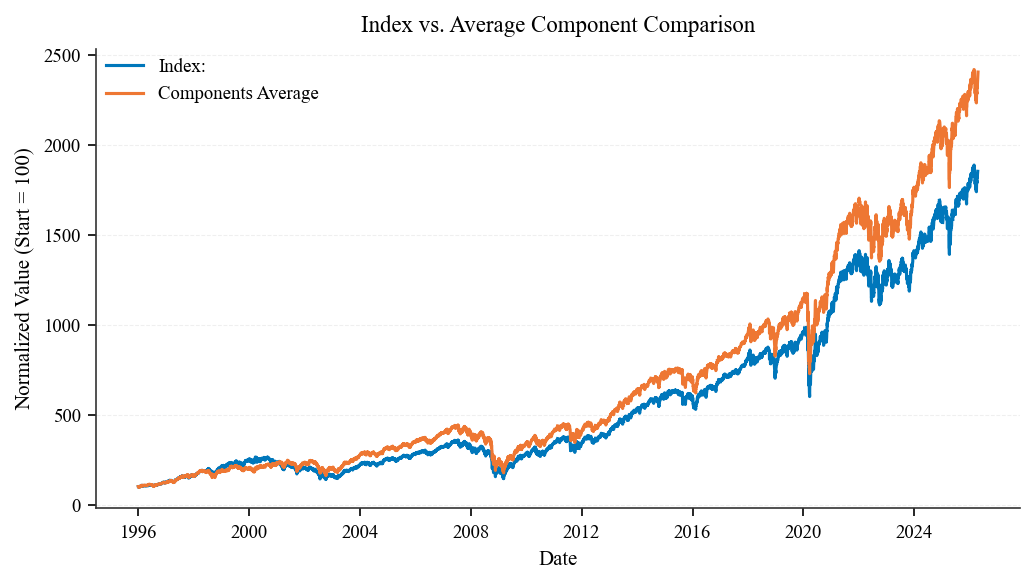

,Index:,Components Average
Date,,
1996-01-02,100.00000000,100.00000000
1996-01-03,100.11275393,100.07400544
1996-01-04,99.53020469,99.32176808
1996-01-05,99.37110588,99.11686200
1996-01-08,99.68179473,99.43635314
...,...,...
2026-04-14,1845.79507395,2356.57018522
2026-04-15,1846.44212898,2359.04651392
2026-04-16,1852.08139624,2368.87908836


In [22]:
import importlib
importlib.reload(features)
importlib.reload(plots)

SP500TR: pd.DataFrame = dataset.YahooFinance.load_ticker("^SP500TR")
ETF_EW: pd.DataFrame = dataset.YahooFinance.load_ticker("RSP")

index: pd.DataFrame = features.merge_index_data(primary_df=ETF_EW, supplemental_df=SP500TR)

plots.plot_index_comparison({
    "Index:": index,
    "Components Average": companies_average["Adj_Close"],
}, normalize=True, filename="22-index-comparison.png")